# MVTec AD Data Exploration

This notebook validates the dataset manifest, examines dataset composition and leakage, reviews representative samples and preprocessing characteristics, compares normal train/test acquisition statistics, and analyzes defect size, shape, and location.

In [7]:
import cv2
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

tqdm.pandas()

In [8]:
pd.set_option('display.max_colwidth', 200)

In [9]:
data_path = Path("../../data/raw/mvtec_ad")
# list(data_path.iterdir())

## 1. Build the dataset manifest

In [10]:
def get_image_metadata(path: str | Path) -> tuple[int | None, int | None, str | None]:
    """Return image width, height, and Pillow mode without loading pixel data.
    Uses PIL to efficiently obtain the image metadata by reading the image header only, without loading the whole image.
    
    Parameters
    ----------
    path : str or Path
        Path to the image file.
    
    Returns
    -------    
    tuple[int | None, int | None, str | None]
        Width, height, and Pillow image mode. Common modes include:  
        ``L``: 8-bit grayscale (0-255)  
        ``RGB``: 3-channels  
        ``RGBA``: RGB + alpha transparency, 4 channels  
        ``1``: binary black/white  
        ``P``: palette-based image  
        ``CMYK``: print-style cyan/magenta/yellow/black
    """
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode
    except (UnidentifiedImageError, OSError) as e:
        print(f"Could not read image metadata for {path}:\n{e}")
        return None, None, None

In [11]:
def build_mvtec_manifest(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    rows = []
    unhandled_files = []

    for product_dir in root.iterdir():
        if not product_dir.is_dir():
            continue

        product = product_dir.name

        # train and test images
        for split in ["train", "test"]:
            split_dir = product_dir / split
            if not split_dir.exists():
                continue

            for defect_dir in split_dir.iterdir():
                if not defect_dir.is_dir():
                    continue

                defect_type = defect_dir.name

                for image_path in defect_dir.iterdir():
                    if image_path.suffix.lower() not in image_extensions:
                        unhandled_files.append(image_path)
                        continue
                    
                    width, height, mode = get_image_metadata(image_path)
                    
                    image_id = image_path.stem
                    file_size_bytes = image_path.stat().st_size
                    mask_path = product_dir / "ground_truth" / defect_type / f"{image_id}_mask.png"

                    rows.append({
                        "path": image_path,
                        "filename": image_path.name,
                        "image_id": image_id,
                        "product": product,
                        "split": split,
                        "defect_type": defect_type,
                        "kind": "image",
                        "is_good": defect_type == "good",
                        "is_defect": split == "test" and defect_type != "good",
                        "has_mask": mask_path.exists(),
                        "mask_path": str(mask_path) if mask_path.exists() else None,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if width and height else None,
                        "megapixels": width * height / 1_000_000 if width and height else None,
                        "file_size_bytes": file_size_bytes,
                        "file_size_kb": round(file_size_bytes / 1024, 2),
                        "suffix": image_path.suffix.lower(),
                    })

        # ground truth masks
        gt_dir = product_dir / "ground_truth"
        if gt_dir.exists():
            for defect_dir in gt_dir.iterdir():
                if not defect_dir.is_dir():
                    continue

                defect_type = defect_dir.name

                for mask_path in defect_dir.iterdir():
                    if mask_path.suffix.lower() not in image_extensions:
                        unhandled_files.append(mask_path)
                        continue

                    width, height, mode = get_image_metadata(mask_path)

                    image_id = mask_path.stem.removesuffix("_mask")
                    file_size_bytes = mask_path.stat().st_size

                    rows.append({
                        "path": mask_path,
                        "filename": mask_path.name,
                        "image_id": image_id,
                        "product": product,
                        "split": "ground_truth",
                        "defect_type": defect_type,
                        "kind": "mask",
                        "is_good": False,
                        "is_defect": False,
                        "has_mask": False,
                        "mask_path": None,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if width and height else None,
                        "megapixels": width * height / 1_000_000 if width and height else None,
                        "file_size_bytes": file_size_bytes,
                        "file_size_kb": round(file_size_bytes / 1024, 2),
                        "suffix": mask_path.suffix.lower(),
                    })

    df = pd.DataFrame(rows)

    if not df.empty:
        df["path"] = df["path"].astype(str)
        
    if unhandled_files:
        print(f'There were {len(unhandled_files)} files not taken into consideration, e.g.: {unhandled_files[:3]}')

    return df

In [12]:
df = build_mvtec_manifest(data_path)

display(df.head())
display(
    df.groupby(['kind', 'split'], dropna=False)
    .size()
    .rename('file_count')
    .to_frame()
)

,path,filename,image_id,product,split,defect_type,kind,is_good,is_defect,has_mask,mask_path,width,height,mode,aspect_ratio,megapixels,file_size_bytes,file_size_kb,suffix
0,../../data/raw/mvtec_ad/tile/train/good/171.png,171.png,171,tile,train,good,image,True,False,False,NaN,840,840,RGB,1.0,0.7056,987579,964.43,.png
1,../../data/raw/mvtec_ad/tile/train/good/128.png,128.png,128,tile,train,good,image,True,False,False,NaN,840,840,RGB,1.0,0.7056,991881,968.63,.png
2,../../data/raw/mvtec_ad/tile/train/good/033.png,033.png,033,tile,train,good,image,True,False,False,NaN,840,840,RGB,1.0,0.7056,1032498,1008.30,.png
3,../../data/raw/mvtec_ad/tile/train/good/073.png,073.png,073,tile,train,good,image,True,False,False,NaN,840,840,RGB,1.0,0.7056,1034417,1010.17,.png
4,../../data/raw/mvtec_ad/tile/train/good/204.png,204.png,204,tile,train,good,image,True,False,False,NaN,840,840,RGB,1.0,0.7056,999734,976.30,.png


file_count
kind  split                   
image test                1725
      train               3629
mask  ground_truth        1258

In [13]:
image_df = df[df['kind'].eq('image')].copy()
mask_df = df[df['kind'].eq('mask')].copy()

image_df['subset'] = np.select(
    [
        image_df['split'].eq('train') & image_df['is_good'],
        image_df['split'].eq('test') & image_df['is_good'],
        image_df['split'].eq('test') & image_df['is_defect'],
    ],
    ['train_good', 'test_good', 'test_defect'],
    default='other',
)

assert image_df.shape[0] == 5354, 'Some images seem to be missing!'
assert mask_df.shape[0] == 1258, 'Some mask images seem to be missing!'


### Manifest integrity

Validate the structural assumptions required by all later analyses using only the loaded manifest metadata.

In [14]:
defective_images = image_df[image_df['is_defect']]
good_images = image_df[image_df['is_good']]
pairing_columns = ['product', 'defect_type', 'image_id']

paired_defects = defective_images.merge(
    mask_df,
    on=pairing_columns,
    how='outer',
    suffixes=('_image', '_mask'),
    indicator=True,
    validate='one_to_one',
)
paired_rows = paired_defects['_merge'].eq('both')
dimensions_match = (
    paired_defects.loc[paired_rows, 'width_image'].eq(
        paired_defects.loc[paired_rows, 'width_mask']
    )
    & paired_defects.loc[paired_rows, 'height_image'].eq(
        paired_defects.loc[paired_rows, 'height_mask']
    )
)

manifest_checks = pd.Series({
    'all files have image metadata': df[['width', 'height', 'mode']].notna().all(axis=1).all(),
    'every defective test image has a mask': defective_images['has_mask'].all(),
    'good images have no masks': not good_images['has_mask'].any(),
    'image-mask pairing is complete': paired_rows.all(),
    'paired image-mask dimensions match': dimensions_match.all(),
    'all masks use grayscale mode': mask_df['mode'].eq('L').all(),
}, name='passed')

display(manifest_checks)
assert manifest_checks.all(), 'One or more manifest integrity checks failed.' 

all files have image metadata            True
every defective test image has a mask    True
good images have no masks                True
image-mask pairing is complete           True
paired image-mask dimensions match       True
all masks use grayscale mode             True
Name: passed, dtype: bool

## 2. Dataset composition

Quantify the one-class training setup, product imbalance, and the defect types represented in the test set.

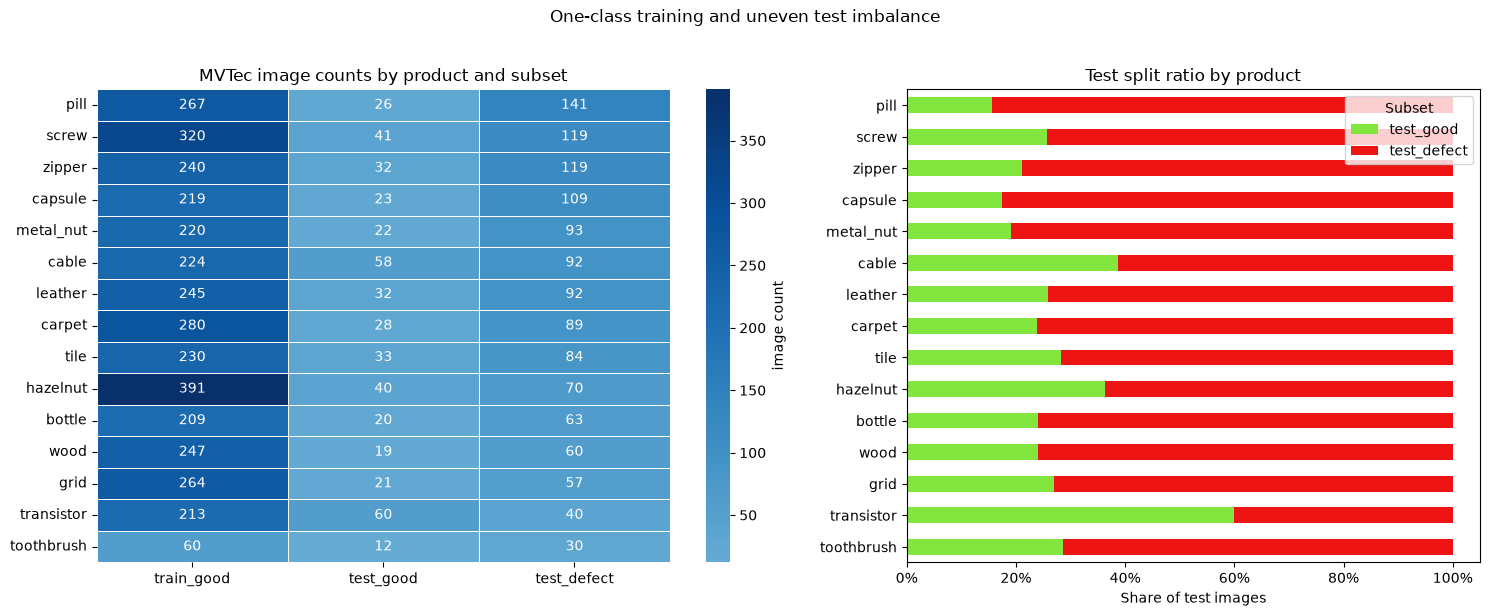

In [15]:
count_table = (
    image_df.groupby(['product', 'subset'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['train_good', 'test_good', 'test_defect'], fill_value=0)
    .sort_values('test_defect', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), width_ratios=[1.25, 1])

sns.heatmap(
    count_table,
    center=0,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'image count'},
    ax=axes[0],
)
axes[0].set_title('MVTec image counts by product and subset')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

test_mix = count_table[['test_good', 'test_defect']]
test_mix_pct = test_mix.div(test_mix.sum(axis=1), axis=0)#.sort_values('test_defect')
test_mix_pct.plot(kind='barh', stacked=True, ax=axes[1], color=["#82e63f", "#ee1414"])
axes[1].invert_yaxis()
axes[1].set_title('Test split ratio by product')
axes[1].set_xlabel('Share of test images')
axes[1].set_ylabel('')
axes[1].legend(title='Subset', loc='upper right')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

fig.suptitle('One-class training and uneven test imbalance', y=1.02)
fig.tight_layout()
plt.show()

Based on the results, we can see that there is an imbalance in the test set between defect-free and defective samples, and the degree of imbalance varies by product type as well. Hence, Therefore, accuracy alone is not suffienct for evaulating model performance, and metrics like precision, refcall, F1-score and AUROC should be considered.

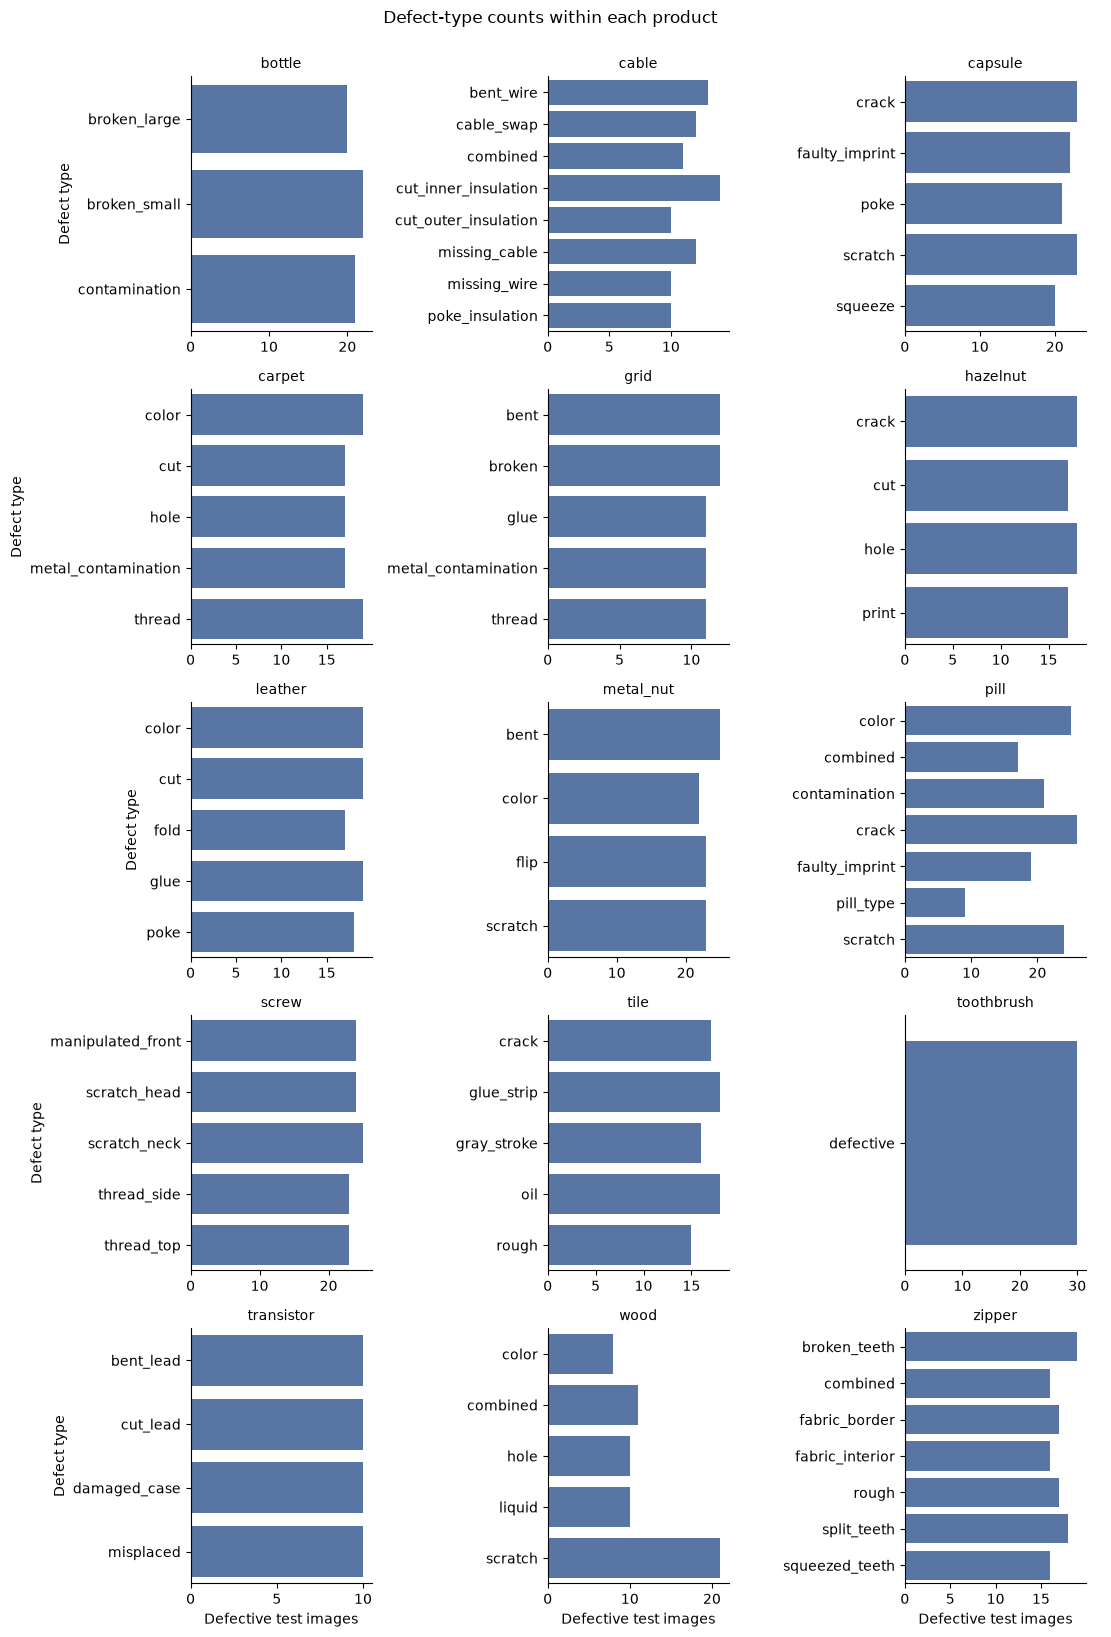

In [16]:
defect_counts = (
    image_df[image_df['is_defect']]
    .groupby(['product', 'defect_type'])
    .size()
    .rename('image_count')
    .reset_index()
)

g = sns.catplot(
    data=defect_counts,
    x='image_count',
    y='defect_type',
    col='product',
    col_wrap=3,
    kind='bar',
    sharey=False,
    sharex=False,
    height=3.2,
    aspect=1.15,
    color='#4c72b0',
)
g.set_axis_labels('Defective test images', 'Defect type')
g.set_titles('{col_name}')
g.figure.suptitle('Defect-type counts within each product', y=1.02)
plt.show()

## 3. Exact duplicates and train/test leakage

SHA-256 hashes identify byte-for-byte duplicate images. The cached hashes avoid rereading every file on later notebook runs. Set the flag to `True` after changing the dataset.

In [17]:
def calculate_sha256(path: str | Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open('rb') as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

REBUILD_FILE_HASHES = False
hash_cache_path = data_path.parent / 'cache' / 'image_sha256.parquet'
hash_cache_path.parent.mkdir(parents=True, exist_ok=True)

if REBUILD_FILE_HASHES or not hash_cache_path.exists():
    image_hashes = image_df[['path']].copy()
    image_hashes['sha256'] = image_hashes['path'].progress_apply(calculate_sha256)
    image_hashes.to_parquet(hash_cache_path, engine='pyarrow', index=False)
    print(f'Saved image hashes to {hash_cache_path}')
else:
    image_hashes = pd.read_parquet(hash_cache_path, engine='pyarrow')
    print(f'Loaded image hashes from {hash_cache_path}')

image_df = (
    image_df.drop(columns='sha256', errors='ignore')
    .merge(image_hashes, on='path', how='left', validate='one_to_one')
)
assert image_df['sha256'].notna().all(), 'Some images are missing hashes.' 

  0%|          | 0/5354 [00:00<?, ?it/s]

Saved image hashes to ../../data/raw/cache/image_sha256.parquet


In [18]:
duplicate_images = image_df[image_df.duplicated('sha256', keep=False)].copy()

duplicate_groups = (
    duplicate_images.groupby('sha256')
    .agg(
        file_count=('path', 'size'),
        products=('product', lambda values: sorted(set(values))),
        splits=('split', lambda values: sorted(set(values))),
        subsets=('subset', lambda values: sorted(set(values))),
        paths=('path', list),
    )
    .sort_values('file_count', ascending=False)
)

if duplicate_groups.empty:
    print('No exact duplicate images found.')
else:
    cross_split_duplicates = duplicate_groups[
        duplicate_groups['splits'].apply(len).gt(1)
    ]
    print(f'Exact duplicate groups: {len(duplicate_groups)}')
    print(f'Groups crossing train/test: {len(cross_split_duplicates)}')
    display(duplicate_groups)
    assert cross_split_duplicates.empty, 'Exact train/test leakage detected.' 

No exact duplicate images found.


## 4. Sample images

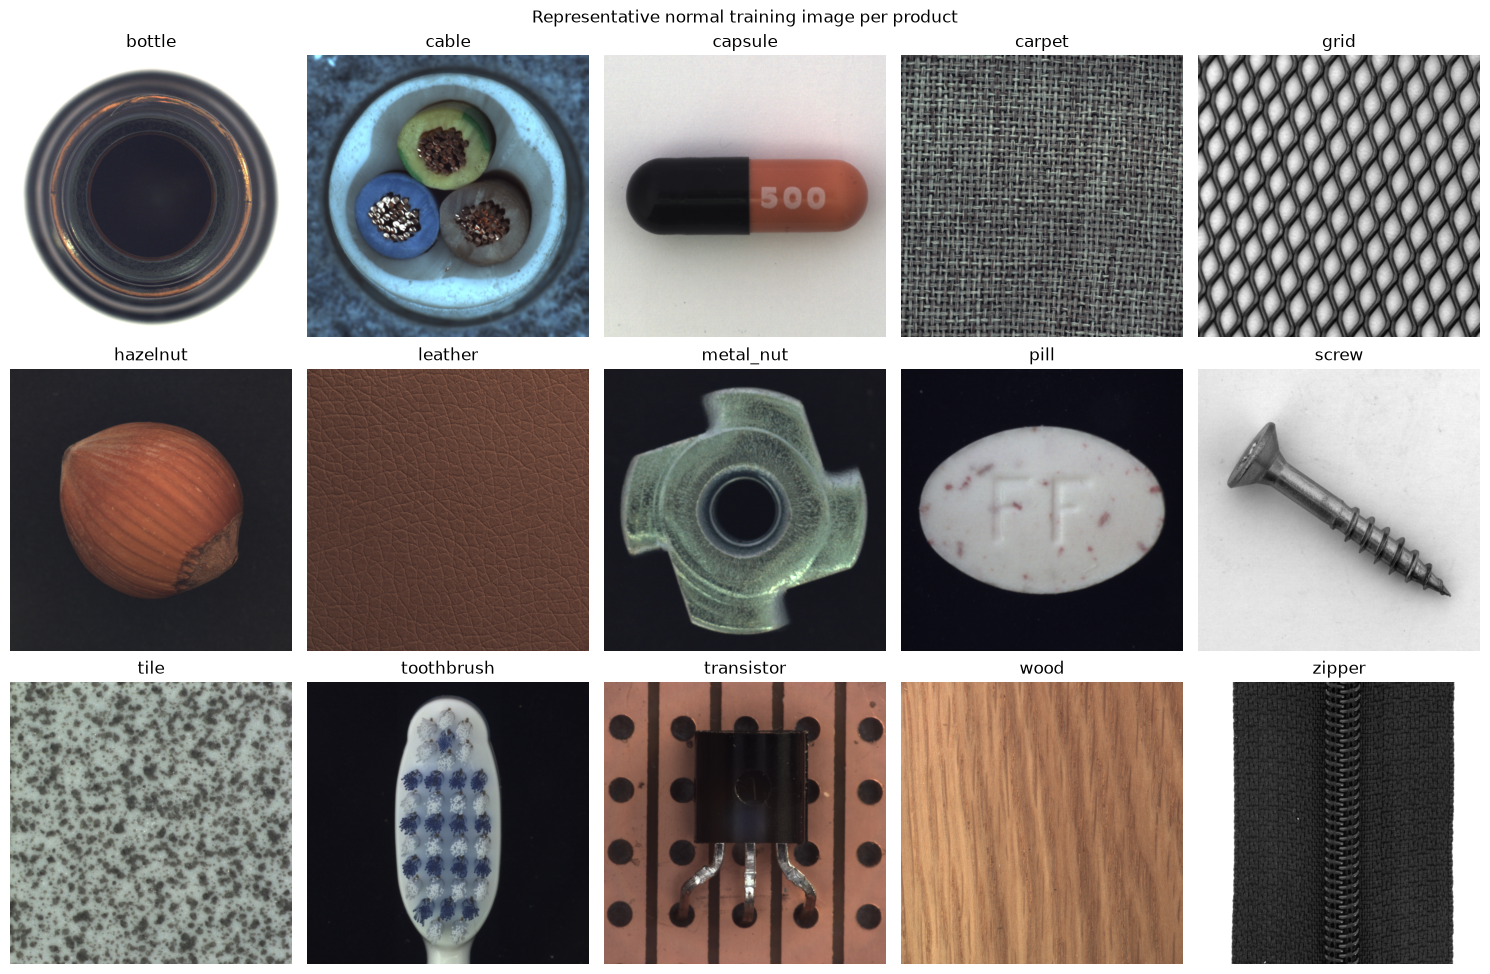

In [19]:
def load_image_for_display(path: str | Path, mode: str) -> np.ndarray:
    if mode == 'RGB':
        image = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image is None:
            raise ValueError(f'Could not decode {path}')
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if mode == 'L':
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f'Could not decode {path}')
        return image
    raise ValueError(f'Unsupported image mode: {mode}')

normal_samples = image_df[image_df['subset'].eq('train_good')].groupby('product').sample(n=1, random_state=12).sort_values('product')

fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, (_, row) in zip(axes.flat, normal_samples.iterrows(), strict=True):
    image = load_image_for_display(row['path'], row['mode'])
    ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
    ax.set_title(row['product'])
    ax.axis('off')
fig.suptitle('Representative normal training image per product')
plt.tight_layout()
plt.show()

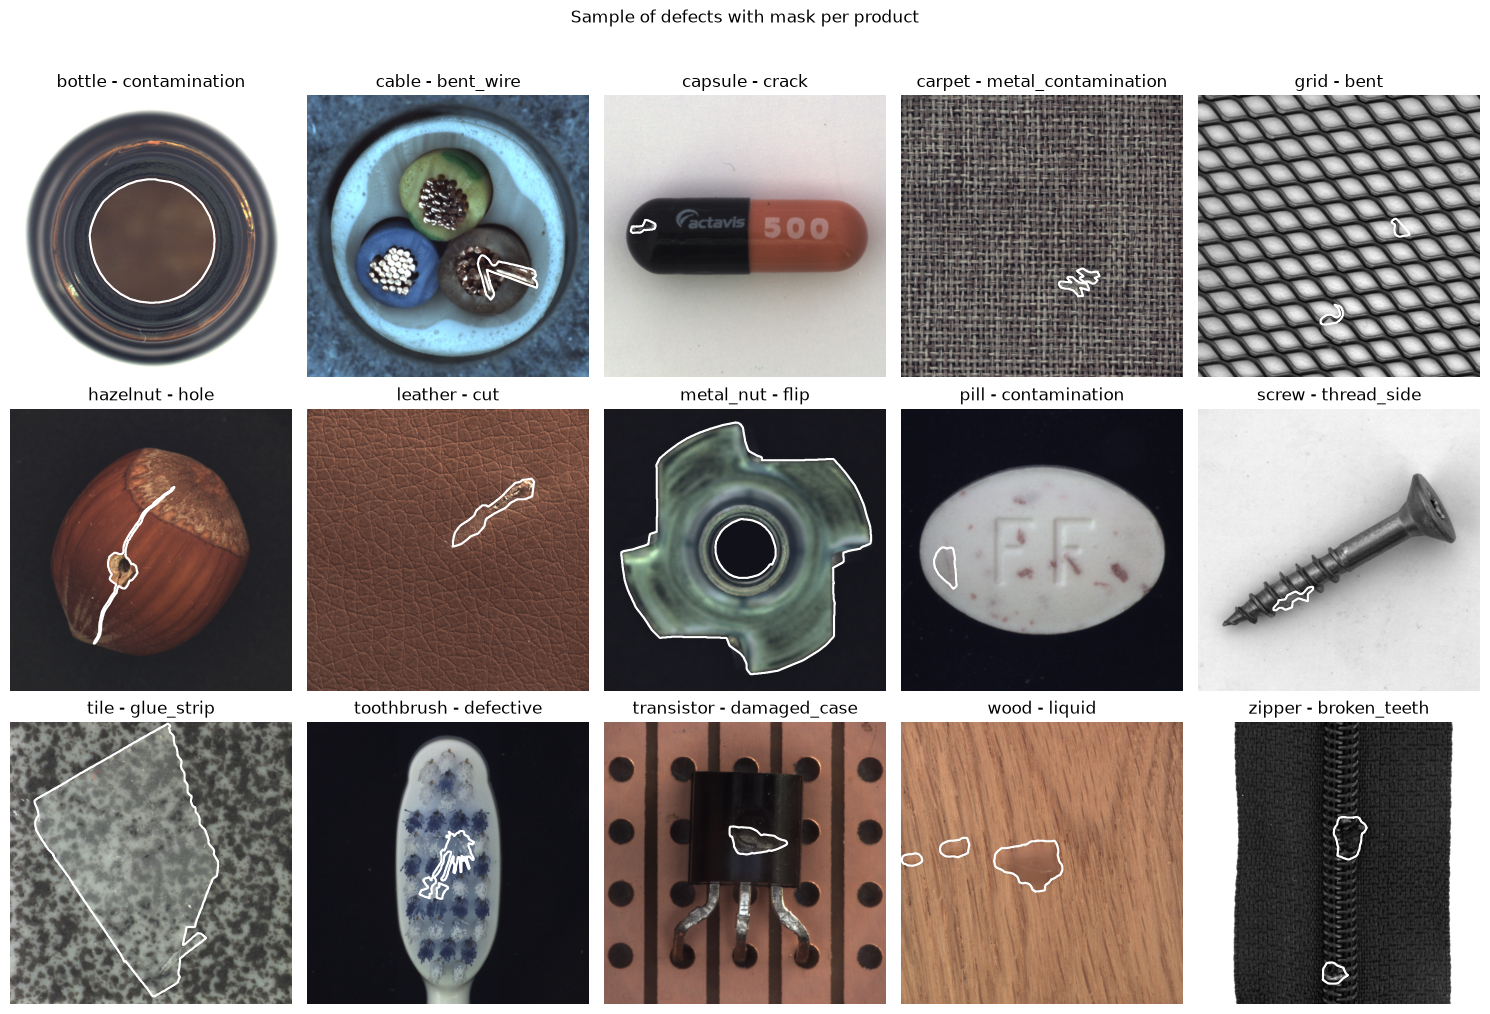

In [20]:
defect_samples = image_df[image_df['is_defect']].groupby('product').sample(n=1, random_state=12).sort_values('product')

fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, (_, row) in zip(axes.flat, defect_samples.iterrows(), strict=True):
    image = load_image_for_display(row['path'], row['mode'])
    mask = cv2.imread(str(row['mask_path']), cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
    
    # ------------ view mask as an overlay -----------
    # ax.imshow(mask, cmap='Reds', alpha=0.25, vmin=0, vmax=255)
    
    # -------- view mask boundary only ------------
    ax.contour(mask > 0, levels=[0.5], colors="white", linewidths=1.5)
    
    ax.set_title(f"{row['product']} - {row['defect_type']}")
    ax.axis('off')
fig.suptitle('Sample of defects with mask per product', y=1.02)
plt.tight_layout()
plt.show()

## 5. Image modes and dimensions

Review format and resolution differences that affect resizing, channel handling, and model preprocessing.

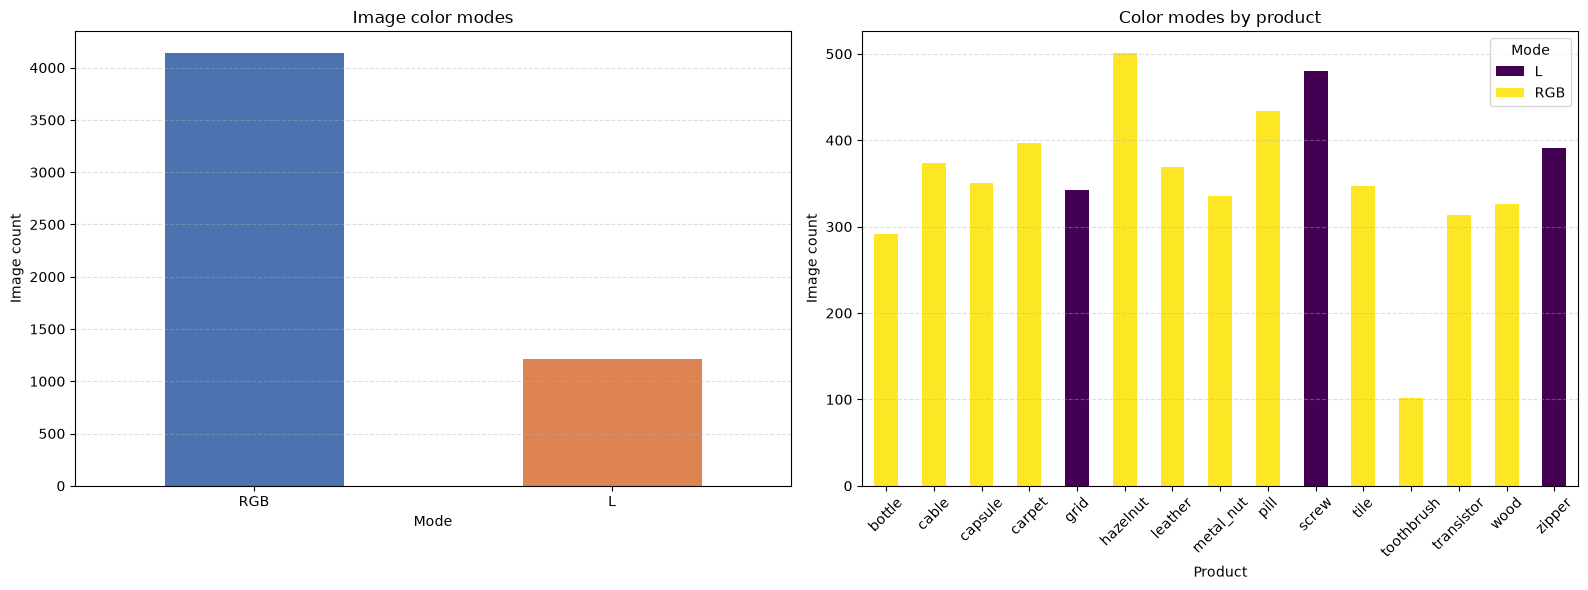

In [21]:
mode_by_product = (
    image_df.groupby(['product', 'mode'])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
image_df['mode'].value_counts().plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'])
axes[0].set_title('Image color modes')
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Image count')
axes[0].tick_params(axis='x', rotation=0)

mode_by_product.plot(kind='bar', stacked=True, ax=axes[1], cmap='viridis')
axes[1].set_title('Color modes by product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Image count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Mode')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [22]:
image_df['width'].unique()

array([ 840, 1024,  800,  900,  700, 1000])

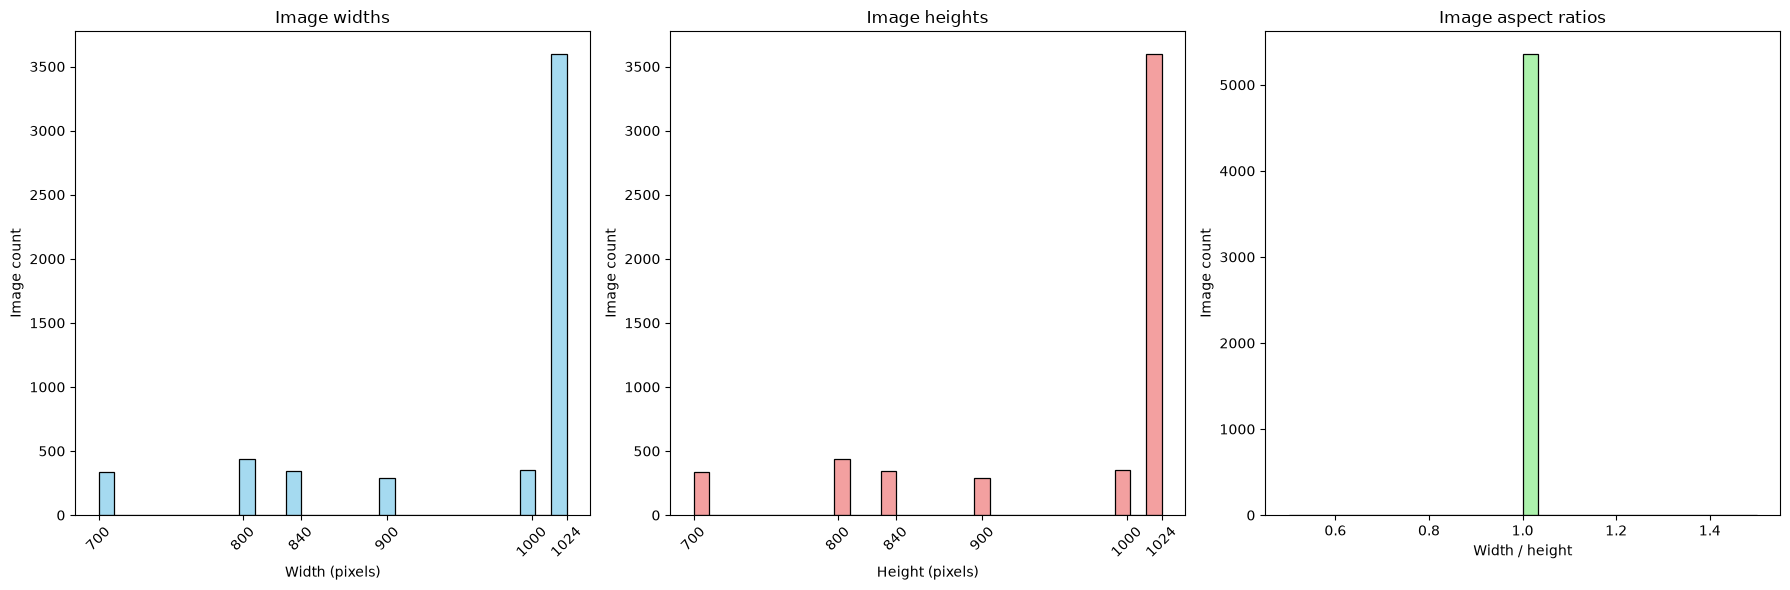

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ticks = image_df['width'].unique()
sns.histplot(image_df['width'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Image widths')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_xticks(ticks, ticks, rotation=45)

sns.histplot(image_df['height'], bins=30, ax=axes[1], color='lightcoral')
axes[1].set_title('Image heights')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_xticks(ticks, ticks, rotation=45)


sns.histplot(image_df['aspect_ratio'], bins=30, ax=axes[2], color='lightgreen')
axes[2].set_title('Image aspect ratios')
axes[2].set_xlabel('Width / height')

for ax in axes:
    ax.set_ylabel('Image count')
plt.tight_layout()
plt.show()

## 6. Normal train/test pixel statistics

Brightness and contrast are compared within products to identify acquisition shift. These global statistics are quality and domain-shift indicators, not direct detectors of localized defects.

In [24]:
def calculate_pixel_statistics(image_path: str | Path, mode: str) -> pd.Series:
    """Calculate comparable luminance statistics and optional RGB-channel statistics."""
    feature_names = [
        'intensity_mean', 'intensity_std', 'intensity_p05',
        'intensity_median', 'intensity_p95', 'intensity_range_p90',
        'red_mean', 'green_mean', 'blue_mean',
        'red_std', 'green_std', 'blue_std',
    ]

    try:
        if mode == 'RGB':
            bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
            if bgr is None:
                raise ValueError('OpenCV could not decode the image')
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            luminance = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
            channel_means = rgb.mean(axis=(0, 1))
            channel_stds = rgb.std(axis=(0, 1))
        elif mode == 'L':
            luminance = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if luminance is None:
                raise ValueError('OpenCV could not decode the image')
            channel_means = [np.nan] * 3
            channel_stds = [np.nan] * 3
        else:
            raise ValueError(f'Unsupported image mode: {mode}')

        p05, median, p95 = np.percentile(luminance, [5, 50, 95])
        values = [
            luminance.mean(), luminance.std(), p05, median, p95, p95 - p05,
            *channel_means, *channel_stds,
        ]
        return pd.Series(dict(zip(feature_names, values, strict=True)))
    except (OSError, ValueError) as error:
        print(f'Could not calculate pixel statistics for {image_path}: {error}')
        return pd.Series({name: np.nan for name in feature_names})

In [27]:
REBUILD_PIXEL_FEATURES = False

pixel_feature_columns = [
    'intensity_mean', 'intensity_std', 'intensity_p05',
    'intensity_median', 'intensity_p95', 'intensity_range_p90',
    'red_mean', 'green_mean', 'blue_mean',
    'red_std', 'green_std', 'blue_std',
]
pixel_cache_path = data_path.parent / 'cache' / 'image_pixel_features.parquet'
pixel_cache_path.parent.mkdir(parents=True, exist_ok=True)

if REBUILD_PIXEL_FEATURES or not pixel_cache_path.exists():
    print('Calculating pixel statistics for all images...')
    calculated_features = image_df.progress_apply(
        lambda row: calculate_pixel_statistics(row['path'], row['mode']),
        axis=1,
    )
    pixel_features = pd.concat(
        [image_df[['path']].reset_index(drop=True),
         calculated_features.reset_index(drop=True)],
        axis=1,
    )
    pixel_features.to_parquet(pixel_cache_path, engine='pyarrow', index=False)
    print(f'Saved pixel features to {pixel_cache_path}')
else:
    pixel_features = pd.read_parquet(pixel_cache_path, engine='pyarrow')
    print(f'Loaded pixel features from {pixel_cache_path}')

image_df = (
    image_df.drop(columns=pixel_feature_columns, errors='ignore')
    .merge(
        pixel_features[['path', *pixel_feature_columns]],
        on='path',
        how='left',
        validate='one_to_one',
    )
)

assert image_df[pixel_feature_columns].notna().any(axis=1).all(), (
    'Some images did not produce pixel statistics.'
)

Calculating pixel statistics for all images...


  0%|          | 0/5354 [00:00<?, ?it/s]

Saved pixel features to ../../data/raw/cache/image_pixel_features.parquet


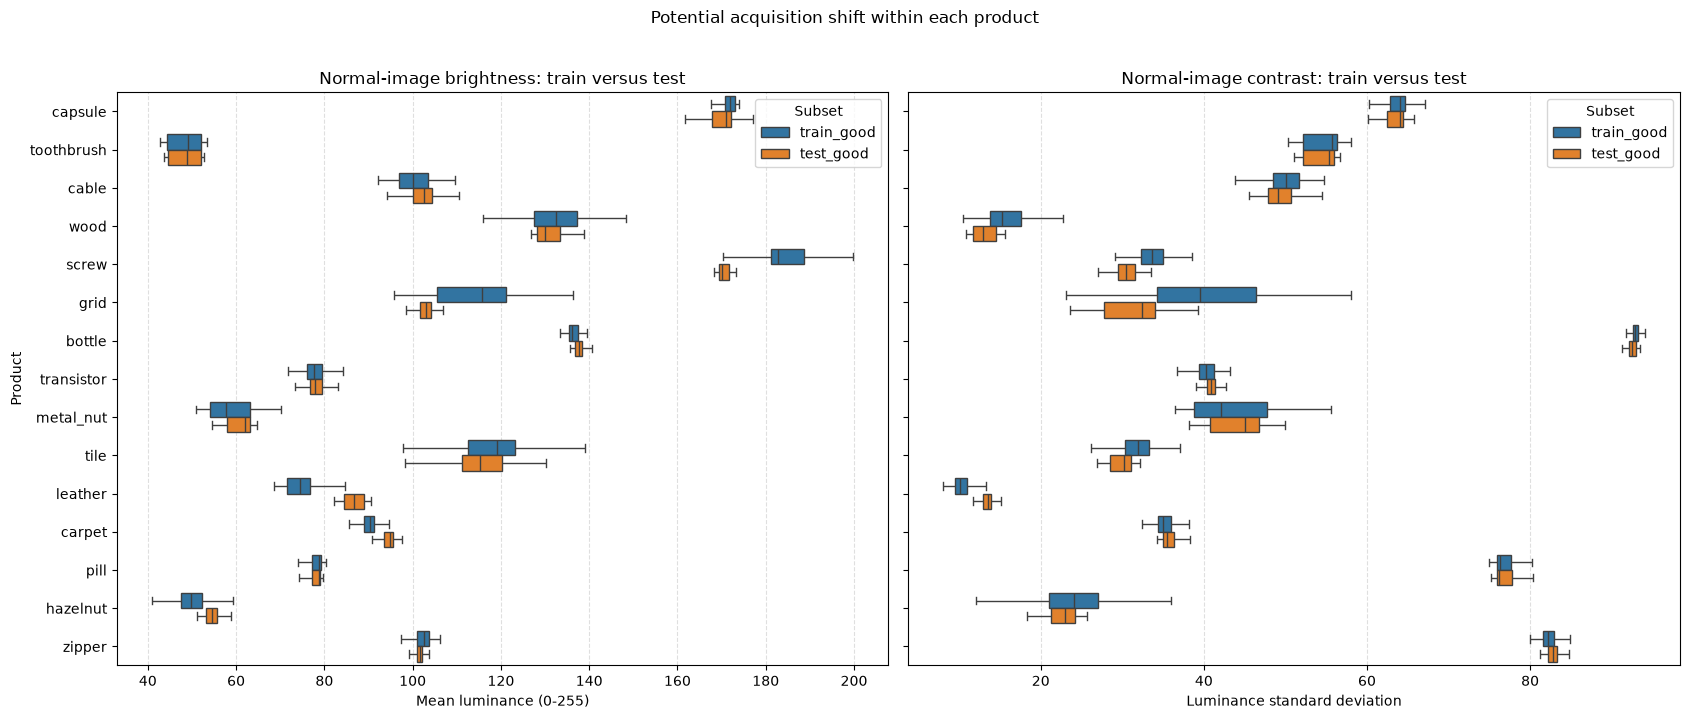

In [ ]:
normal_images = image_df[image_df['subset'].isin(['train_good', 'test_good'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharey=True)

sns.boxplot(
    data=normal_images,
    y='product',
    x='intensity_mean',
    hue='subset',
    ax=axes[0],
    showfliers=False,
)
axes[0].set_title('Normal-image brightness: train versus test')
axes[0].set_xlabel('Mean luminance (0-255)')
axes[0].set_ylabel('Product')

sns.boxplot(
    data=normal_images,
    y='product',
    x='intensity_std',
    hue='subset',
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title('Normal-image contrast: train versus test')
axes[1].set_xlabel('Luminance standard deviation')
axes[1].set_ylabel('')

for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(title='Subset', loc='best')

fig.suptitle('Potential acquisition shift within each product', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
normal_intensity_summary = (
    normal_images.groupby(['product', 'subset'], observed=True)
    .agg(
        image_count=('path', 'size'),
        mean_luminance=('intensity_mean', 'mean'),
        mean_contrast=('intensity_std', 'mean'),
        mean_p90_range=('intensity_range_p90', 'mean'),
    )
    .unstack('subset')
)

for metric in ['mean_luminance', 'mean_contrast', 'mean_p90_range']:
    normal_intensity_summary[(metric, 'test_minus_train')] = (
        normal_intensity_summary[(metric, 'test_good')]
        - normal_intensity_summary[(metric, 'train_good')]
    )

normal_intensity_summary = normal_intensity_summary.sort_values(
    ('mean_luminance', 'test_minus_train'),
    key=abs,
    ascending=False,
)
display(normal_intensity_summary.round(2))

image_count            mean_luminance            mean_contrast  \
subset       test_good train_good      test_good train_good     test_good   
product                                                                     
screw               41        320         170.35     184.17         30.54   
leather             32        245          86.82      75.44         13.38   
grid                21        264         104.09     114.18         32.60   
hazelnut            40        391          54.46      49.75         22.76   
carpet              28        280          94.51      90.42         35.74   
tile                33        230         114.92     118.39         29.90   
metal_nut           22        220          60.61      58.66         44.38   
capsule             23        219         170.25     171.95         63.34   
wood                19        247         131.12     132.61         13.08   
cable               58        224         101.87     100.44         49.51   
bottle              20        209         137.67     136.34         92.55   
zipper              32        240         101.60     102.28         82.98   
transistor          60        213          78.21      77.84         40.94   
toothbrush          12         60          48.61      48.54         54.48   
pill                26        267          77.89      77.89         76.97   

                      mean_p90_range              mean_luminance  \
subset     train_good      test_good train_good test_minus_train   
product                                                            
screw           33.60         100.24     111.17           -13.82   
leather         10.31          44.34      33.82            11.38   
grid            39.90          97.67     118.25           -10.09   
hazelnut        24.37          64.82      69.13             4.71   
carpet          35.41         121.79     120.68             4.10   
tile            31.79          91.03      96.53            -3.47   
metal_nut       43.26         120.23     117.25             1.95   
capsule         63.82         198.52     200.21            -1.70   
wood            15.78          43.00      52.12            -1.49   
cable           49.94         169.69     171.34             1.43   
bottle          92.89         219.15     220.06             1.34   
zipper          82.35         219.22     219.00            -0.68   
transistor      40.22         111.03     109.61             0.36   
toothbrush      54.70         153.08     153.18             0.07   
pill            76.99         173.92     174.14            -0.00   

              mean_contrast   mean_p90_range  
subset     test_minus_train test_minus_train  
product                                       
screw                 -3.06           -10.92  
leather                3.06            10.52  
grid                  -7.29           -20.59  
hazelnut              -1.61            -4.31  
carpet                 0.33             1.11  
tile                  -1.88            -5.50  
metal_nut              1.12             2.97  
capsule               -0.49            -1.69  
wood                  -2.70            -9.12  
cable                 -0.43            -1.65  
bottle                -0.34            -0.91  
zipper                 0.63             0.21  
transistor             0.72             1.42  
toothbrush            -0.22            -0.10  
pill                  -0.02            -0.22

There is a difference in brightness and contrast between some products, like screw, leather, grid, and moderately hazelnut and carpet. Hence, per product evaluation and preprocessing should take into account these variations.

## 7. Mask size, shape, and location

Decode every mask once to calculate area, bounding-box, connected-component, border-contact, and centroid features. The simple rebuild flag controls the Parquet cache.

In [ ]:
def calculate_mask_features(mask_path: str | Path) -> pd.Series:
    feature_names = [
        'defect_area_percentage',
        'bbox_width_norm', 'bbox_height_norm', 'bbox_area_percentage',
        'bbox_fill_ratio', 'connected_component_count', 'touches_border',
        'defect_centroid_x', 'defect_centroid_y',
    ]
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return pd.Series({name: np.nan for name in feature_names})

    binary = mask > 0
    rows, cols = np.where(binary)
    if len(rows) == 0:
        return pd.Series({name: np.nan for name in feature_names})

    height, width = mask.shape
    x_min, x_max = cols.min(), cols.max()
    y_min, y_max = rows.min(), rows.max()
    bbox_width = x_max - x_min + 1
    bbox_height = y_max - y_min + 1
    defect_pixels = binary.sum()
    _, component_labels = cv2.connectedComponents(binary.astype(np.uint8), connectivity=8)
    component_count = component_labels.max()
    touches_border = (
        binary[0, :].any() or binary[-1, :].any()
        or binary[:, 0].any() or binary[:, -1].any()
    )

    return pd.Series({
        'defect_area_percentage': 100 * defect_pixels / (width * height),
        'bbox_width_norm': bbox_width / width,
        'bbox_height_norm': bbox_height / height,
        'bbox_area_percentage': 100 * bbox_width * bbox_height / (width * height),
        'bbox_fill_ratio': defect_pixels / (bbox_width * bbox_height),
        'connected_component_count': component_count,
        'touches_border': touches_border,
        'defect_centroid_x': cols.mean(),
        'defect_centroid_y': rows.mean(),
    })

REBUILD_MASK_FEATURES = False
mask_feature_columns = [
    'defect_area_percentage',
    'bbox_width_norm', 'bbox_height_norm', 'bbox_area_percentage',
    'bbox_fill_ratio', 'connected_component_count', 'touches_border',
    'defect_centroid_x', 'defect_centroid_y',
]
mask_cache_path = data_path.parent / 'cache' / 'mask_features.parquet'
mask_cache_path.parent.mkdir(parents=True, exist_ok=True)

if REBUILD_MASK_FEATURES or not mask_cache_path.exists():
    calculated_mask_features = mask_df['path'].progress_apply(calculate_mask_features)
    mask_features = pd.concat(
        [mask_df[['path']].reset_index(drop=True), calculated_mask_features.reset_index(drop=True)],
        axis=1,
    )
    mask_features.to_parquet(mask_cache_path, engine='pyarrow', index=False)
    print(f'Saved mask features to {mask_cache_path}')
else:
    mask_features = pd.read_parquet(mask_cache_path, engine='pyarrow')
    print(f'Loaded mask features from {mask_cache_path}')

mask_df = (
    mask_df.drop(columns=mask_feature_columns, errors='ignore')
    .merge(mask_features[['path', *mask_feature_columns]], on='path', how='left', validate='one_to_one')
)
assert mask_df[mask_feature_columns].notna().all(axis=1).all(), (
    'Some masks did not produce valid features.'
)

Loaded mask features from /home/ali/projects/anomaly-detection/data/cache/mask_features.parquet


### Defect area by product and defect type

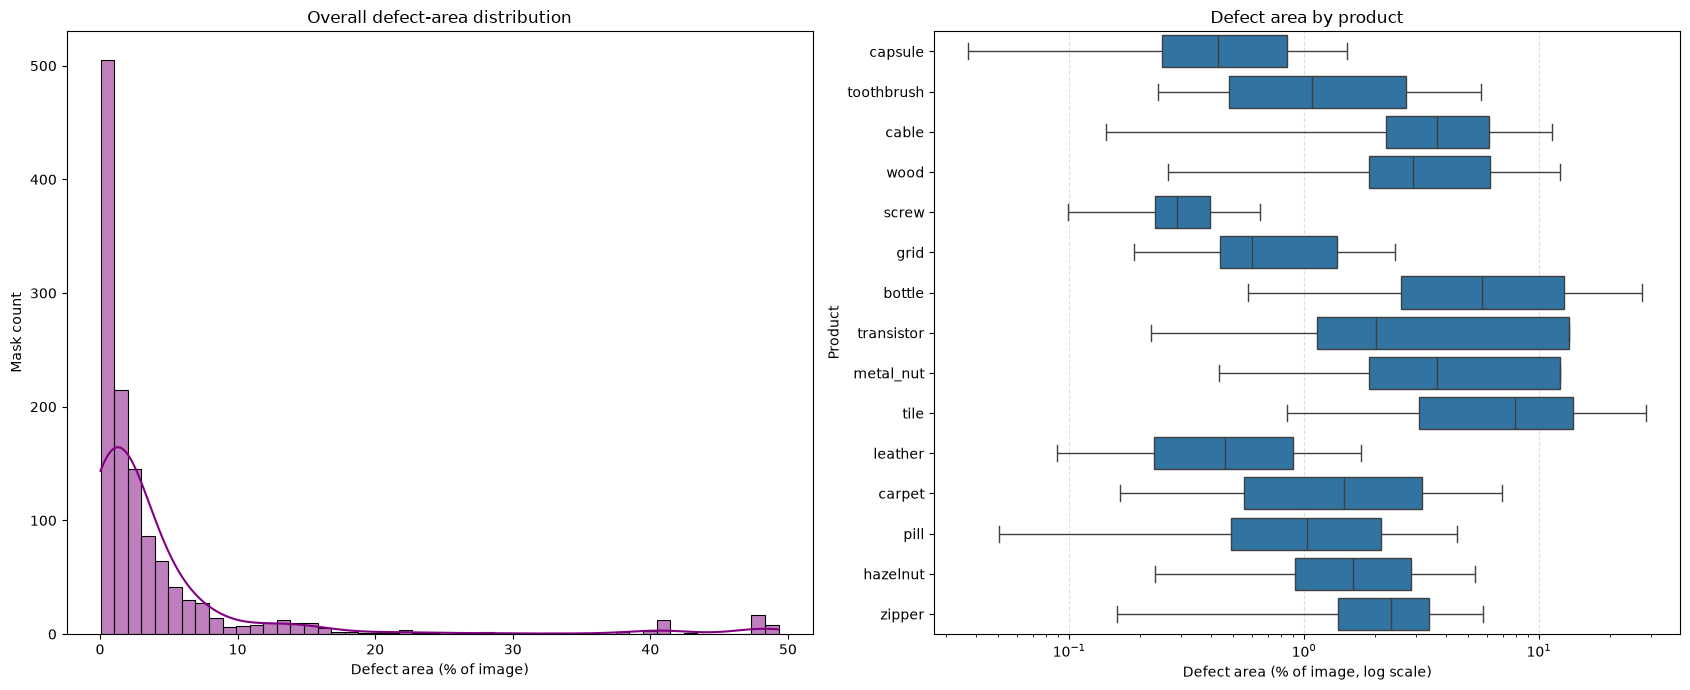

,defect_area_percentage
count,1258.000000
mean,4.388306
std,8.741231
min,0.037100
25%,0.494318
50%,1.543999
75%,3.887486
max,49.320507


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.histplot(mask_df['defect_area_percentage'], bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Overall defect-area distribution')
axes[0].set_xlabel('Defect area (% of image)')
axes[0].set_ylabel('Mask count')

sns.boxplot(
    data=mask_df,
    y='product',
    x='defect_area_percentage',
    showfliers=False,
    ax=axes[1],
)
axes[1].set_xscale('log')
axes[1].set_title('Defect area by product')
axes[1].set_xlabel('Defect area (% of image, log scale)')
axes[1].set_ylabel('Product')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
display(mask_df['defect_area_percentage'].describe().to_frame())

### Consolidated Dataset Imbalance & Defect Distribution Visual (Seaborn)

Below is a consolidated, multi-panel Seaborn chart unifying defect-type breakdowns per category, image-level test set distributions (good vs. anomalous), and pixel-level defect area percentage distributions into a single comprehensive figure using hue color encodings.

In [ ]:
# Consolidated Multi-Panel Visual for MVTec AD Categories, Defect Types, and Imbalances
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Prepare Image-level DataFrame across test splits
test_img_df = df.loc[(df["kind"] == "image") & (df["split"] == "test")].copy()
test_img_df["status"] = np.where(test_img_df["is_good"], "Good (Normal)", "Anomalous (Defect)")

# 2. Prepare Mask-level DataFrame for Pixel-level Defect Imbalance
mask_df_local = df.loc[df["kind"] == "mask"].copy()
if "defect_area_percentage" not in mask_df_local.columns:
    defect_area_pcts = []
    for _, row in mask_df_local.iterrows():
        try:
            m = cv2.imread(str(row["path"]), cv2.IMREAD_GRAYSCALE)
            pct = (np.sum(m > 0) / m.size) * 100.0 if m is not None else np.nan
        except Exception:
            pct = np.nan
        defect_area_pcts.append(pct)
    mask_df_local["defect_area_percentage"] = defect_area_pcts

mask_df_clean = mask_df_local.dropna(subset=["defect_area_percentage"]).copy()

# 3. Compute Category Level Summary Ratios
cat_summary = []
for prod in sorted(test_img_df["product"].unique()):
    prod_imgs = test_img_df[test_img_df["product"] == prod]
    prod_masks = mask_df_clean[mask_df_clean["product"] == prod]
    n_total_test = len(prod_imgs)
    n_anom_test = len(prod_imgs[~prod_imgs["is_good"]])
    img_anom_ratio = (n_anom_test / n_total_test * 100.0) if n_total_test > 0 else 0.0
    mean_pixel_area_pct = prod_masks["defect_area_percentage"].mean() if len(prod_masks) > 0 else 0.0
    cat_summary.append({
        "product": prod,
        "img_anomaly_ratio": img_anom_ratio,
        "pixel_defect_area_mean": mean_pixel_area_pct,
    })
cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_melted = cat_summary_df.melt(
    id_vars=["product"],
    value_vars=["img_anomaly_ratio", "pixel_defect_area_mean"],
    var_name="metric",
    value_name="percentage"
)
metric_map = {
    "img_anomaly_ratio": "Test Set Image Anomaly Ratio (%)",
    "pixel_defect_area_mean": "Mean Defect Area per Anomaly Mask (%)"
}
cat_summary_melted["metric"] = cat_summary_melted["metric"].map(metric_map)

# 4. Plot Multi-Panel Figure using Seaborn
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel A: Test Image Status Distribution by Category
status_order = ["Good (Normal)", "Anomalous (Defect)"]
status_palette = {"Good (Normal)": "#2b5c8f", "Anomalous (Defect)": "#d95f02"}
sns.countplot(
    data=test_img_df,
    y="product",
    hue="status",
    hue_order=status_order,
    palette=status_palette,
    ax=axes[0, 0]
)
axes[0, 0].set_title("A. Test Image Count per Category (Good vs. Anomalous)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Number of Test Images")
axes[0, 0].set_ylabel("Product Category")
axes[0, 0].legend(title="Image Status", frameon=True)

# Panel B: Granular Defect Types per Category
anom_img_df = test_img_df[~test_img_df["is_good"]].copy()
sns.countplot(
    data=anom_img_df,
    y="product",
    hue="defect_type",
    palette="tab20",
    ax=axes[0, 1]
)
axes[0, 1].set_title("B. Defect Type Modal Breakdown per Category", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Anomalous Image Count")
axes[0, 1].set_ylabel("")
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title="Defect Modal Type", fontsize=8)

# Panel C: Pixel-Level Defect Area Distribution per Category
sns.boxplot(
    data=mask_df_clean,
    y="product",
    x="defect_area_percentage",
    palette="crest",
    showfliers=False,
    ax=axes[1, 0]
)
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("C. Pixel-Level Defect Area Distribution (% of Image, Log Scale)", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Defect Area Percentage (Log Scale)")
axes[1, 0].set_ylabel("Product Category")
axes[1, 0].grid(True, which="both", linestyle="--", alpha=0.4)

# Panel D: Image-Level vs Pixel-Level Imbalance Comparison
sns.barplot(
    data=cat_summary_melted,
    y="product",
    x="percentage",
    hue="metric",
    palette=["#7570b3", "#1b9e77"],
    ax=axes[1, 1]
)
axes[1, 1].set_title("D. Image Anomaly Ratio vs. Mean Pixel Defect Area (%)", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Percentage (%)")
axes[1, 1].set_ylabel("")
axes[1, 1].legend(title="Metric Comparison", frameon=True, fontsize=9)

plt.suptitle("Consolidated MVTec AD Dataset Imbalance & Defect Distribution Analysis", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


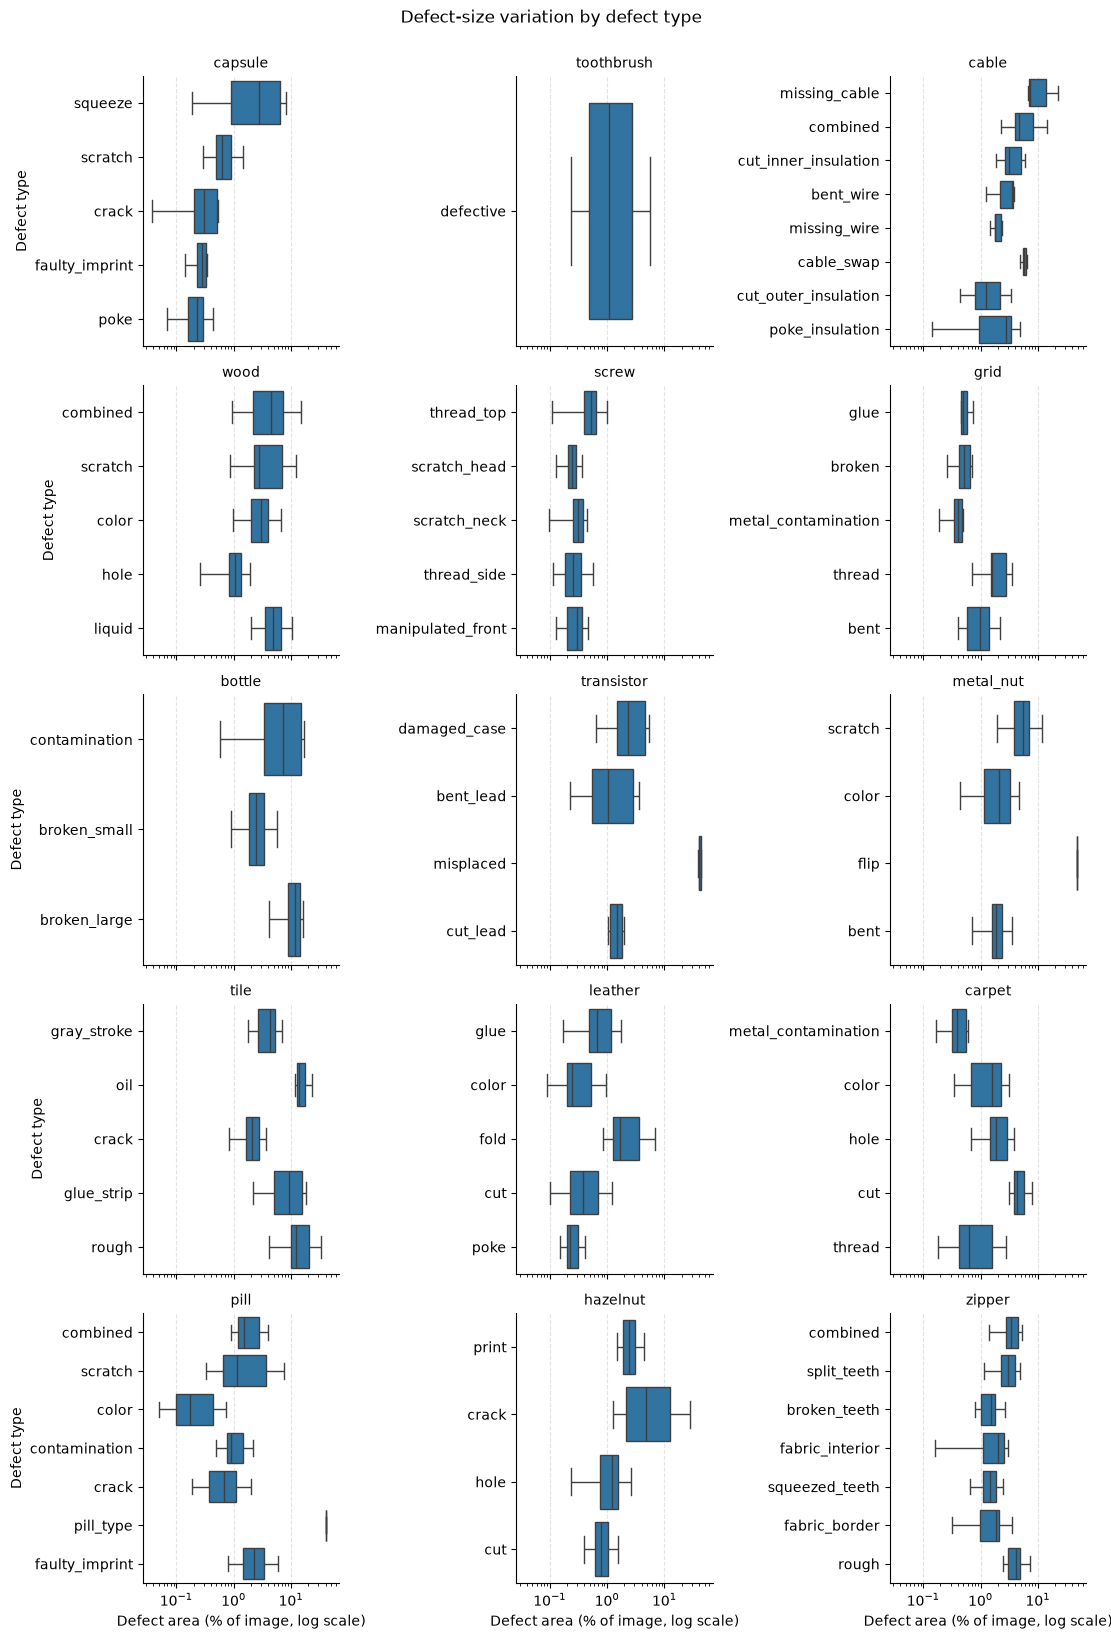

In [ ]:
g = sns.catplot(
    data=mask_df,
    x='defect_area_percentage',
    y='defect_type',
    col='product',
    col_wrap=3,
    kind='box',
    sharey=False,
    showfliers=False,
    height=3.2,
    aspect=1.15,
)
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
g.set_axis_labels('Defect area (% of image, log scale)', 'Defect type')
g.set_titles('{col_name}')
g.fig.suptitle('Defect-size variation by defect type', y=1.02)
plt.show()

### Smallest and largest defects

Overlay examples from both tails of the mask-area distribution to make the numerical scale visually interpretable.

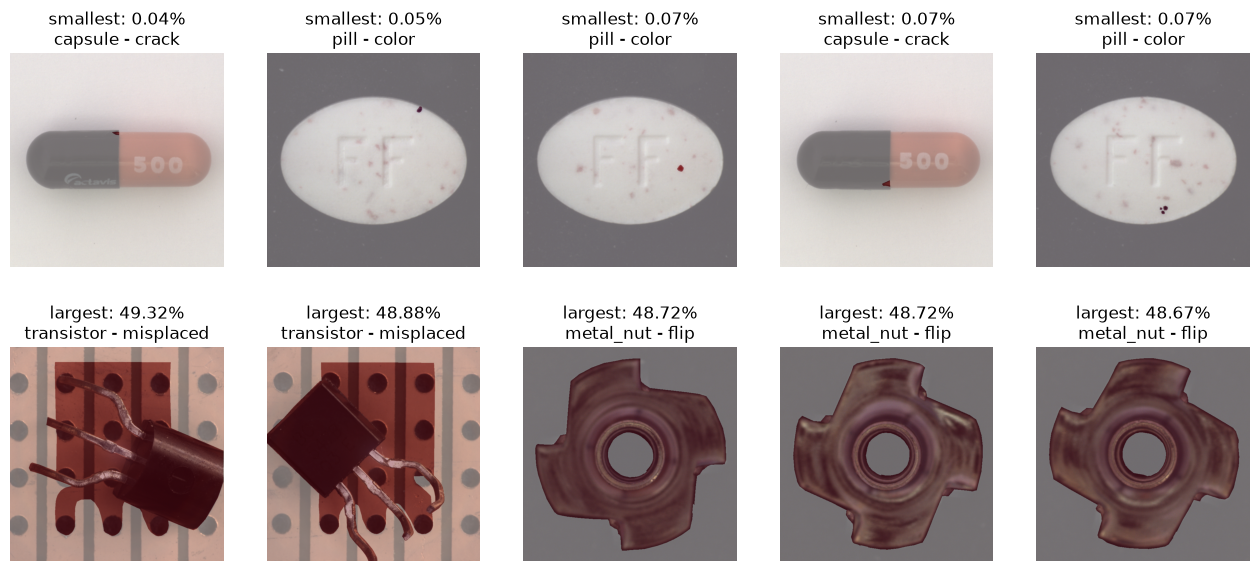

In [ ]:
extreme_masks = pd.concat([
    mask_df.nsmallest(5, 'defect_area_percentage').assign(area_group='smallest'),
    mask_df.nlargest(5, 'defect_area_percentage').assign(area_group='largest'),
])[
    ['product', 'defect_type', 'image_id', 'path', 'defect_area_percentage', 'area_group']
]
extreme_examples = extreme_masks.merge(
    image_df.loc[
        image_df['is_defect'],
        ['product', 'defect_type', 'image_id', 'path', 'mode'],
    ],
    on=['product', 'defect_type', 'image_id'],
    suffixes=('_mask', '_image'),
    validate='one_to_one',
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (_, row) in zip(axes.flat, extreme_examples.iterrows(), strict=True):
    image = load_image_for_display(row['path_image'], row['mode'])
    mask = cv2.imread(str(row['path_mask']), cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
    ax.imshow(mask, cmap='Reds', alpha=0.4, vmin=0, vmax=255)
    ax.set_title(
        f"{row['area_group']}: {row['defect_area_percentage']:.2f}%\n"
        f"{row['product']} - {row['defect_type']}"
    )
    ax.axis('off')
# plt.tight_layout()
plt.show()

### Defect shape and complexity

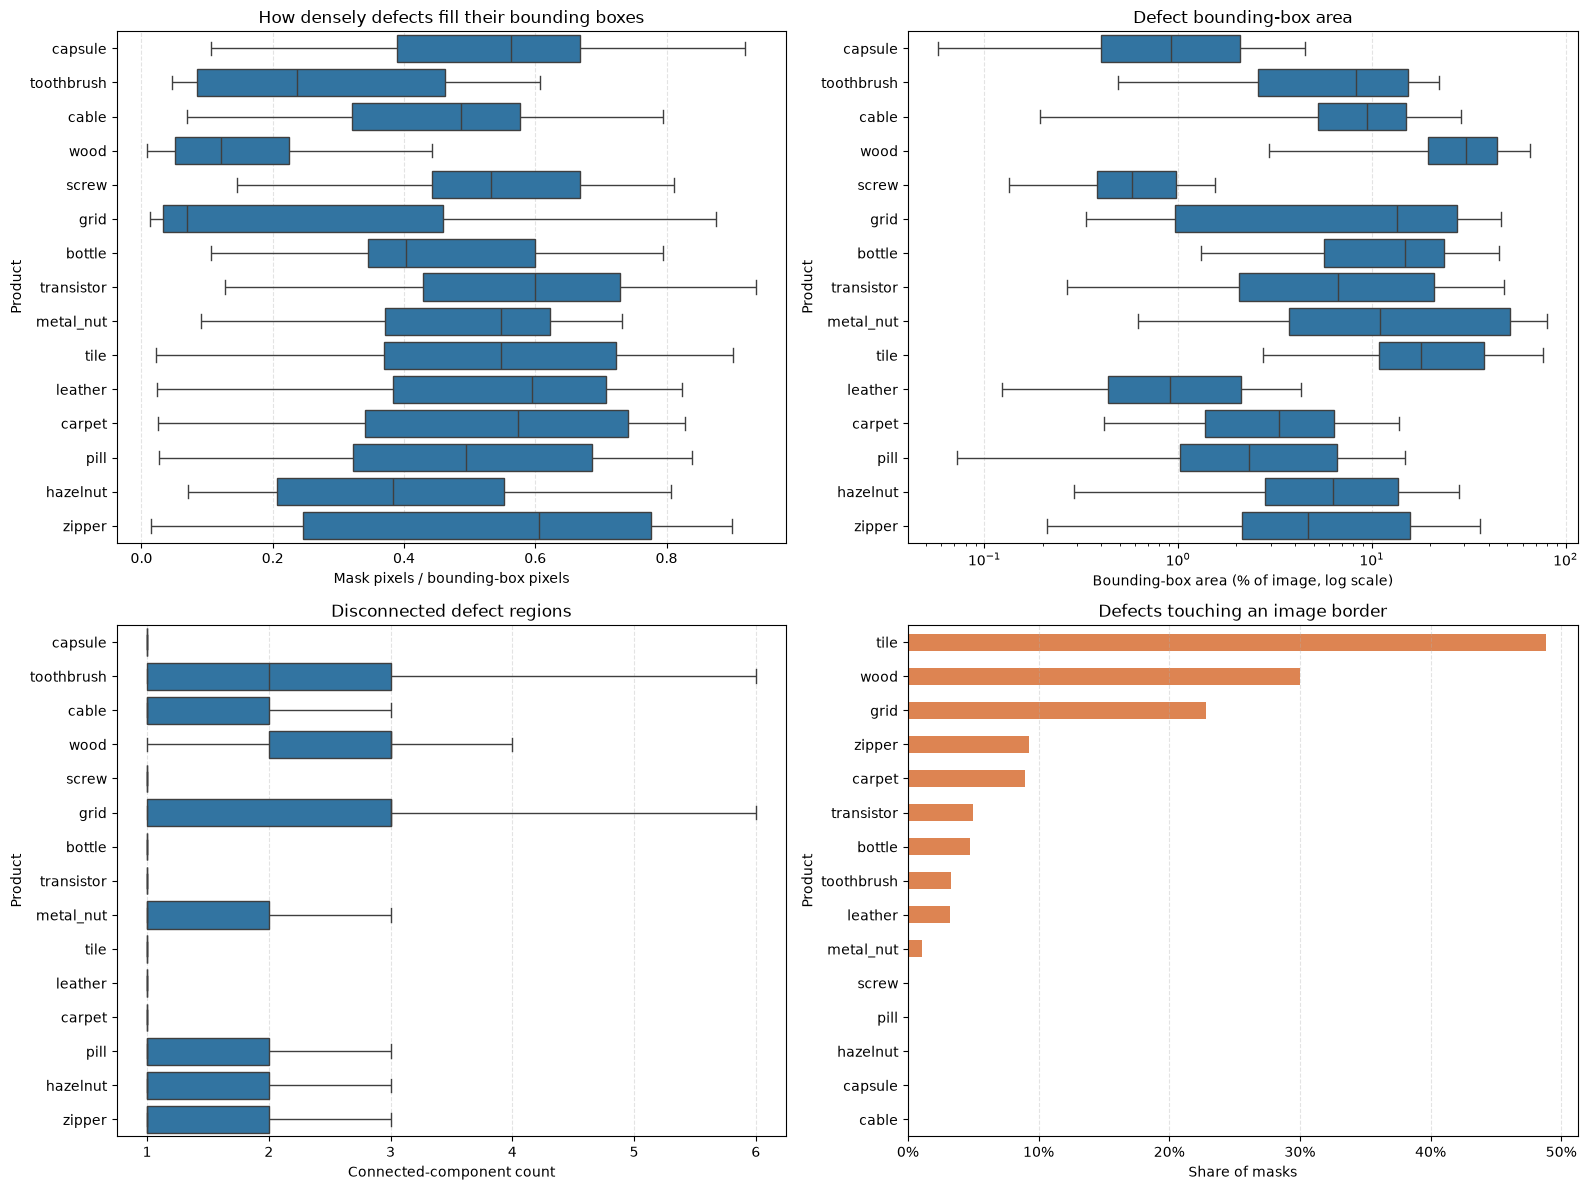

In [ ]:
border_rate = (
    mask_df.groupby('product')['touches_border']
    .mean()
    .sort_values()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=mask_df, y='product', x='bbox_fill_ratio', showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title('How densely defects fill their bounding boxes')
axes[0, 0].set_xlabel('Mask pixels / bounding-box pixels')

sns.boxplot(data=mask_df, y='product', x='bbox_area_percentage', showfliers=False, ax=axes[0, 1])
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Defect bounding-box area')
axes[0, 1].set_xlabel('Bounding-box area (% of image, log scale)')

sns.boxplot(data=mask_df, y='product', x='connected_component_count', showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title('Disconnected defect regions')
axes[1, 0].set_xlabel('Connected-component count')

border_rate.plot(kind='barh', ax=axes[1, 1], color='#dd8452')
axes[1, 1].set_title('Defects touching an image border')
axes[1, 1].set_xlabel('Share of masks')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

for ax in axes.flat:
    ax.set_ylabel('Product')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### Normalized defect location

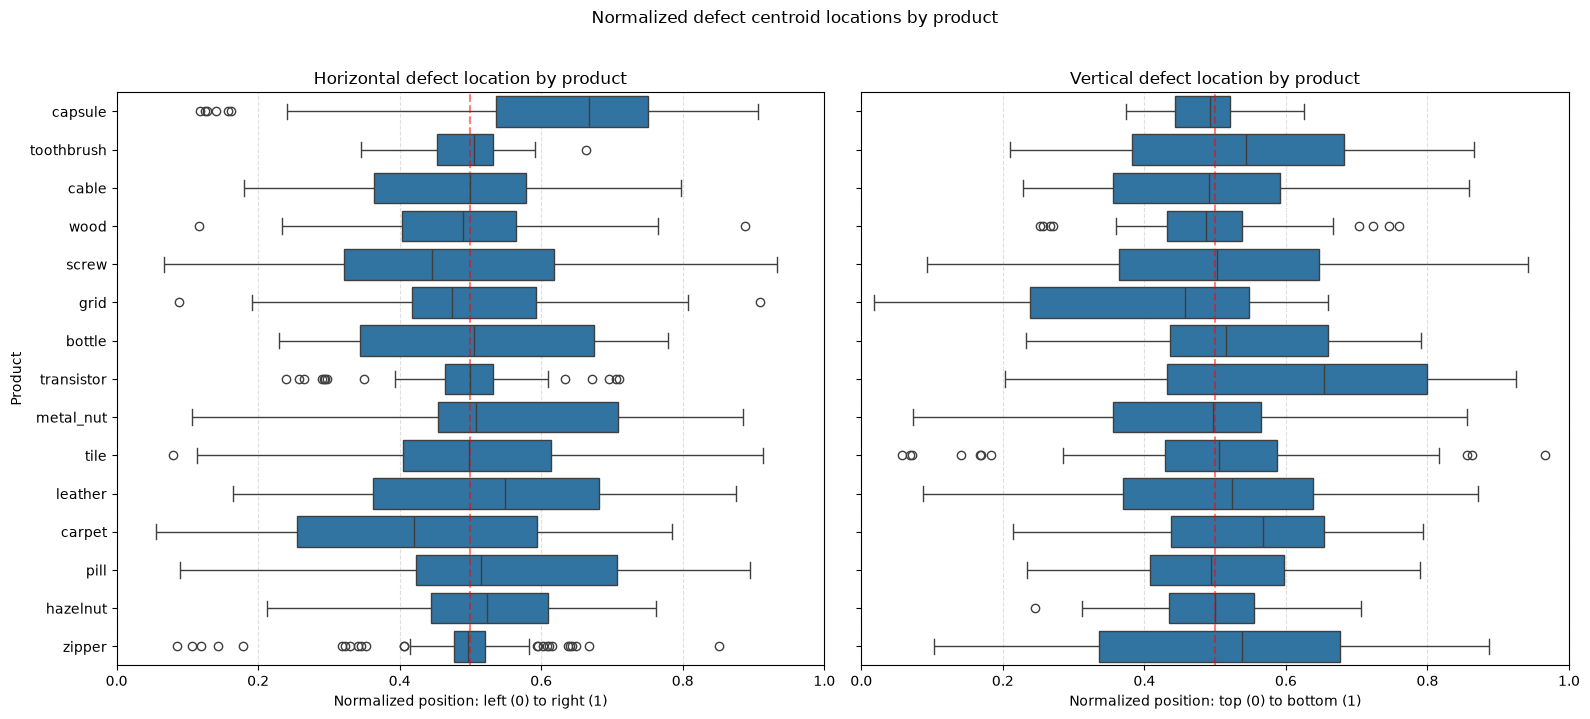

In [ ]:
mask_df['centroid_x_norm'] = mask_df['defect_centroid_x'] / mask_df['width']
mask_df['centroid_y_norm'] = mask_df['defect_centroid_y'] / mask_df['height']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

sns.boxplot(data=mask_df, y='product', x='centroid_x_norm', ax=axes[0])
axes[0].set_title('Horizontal defect location by product')
axes[0].set_xlabel('Normalized position: left (0) to right (1)')
axes[0].set_ylabel('Product')

sns.boxplot(data=mask_df, y='product', x='centroid_y_norm', ax=axes[1])
axes[1].set_title('Vertical defect location by product')
axes[1].set_xlabel('Normalized position: top (0) to bottom (1)')
axes[1].set_ylabel('')

for ax in axes:
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_xlim(0, 1)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle('Normalized defect centroid locations by product', y=1.02)
plt.tight_layout()
plt.show()

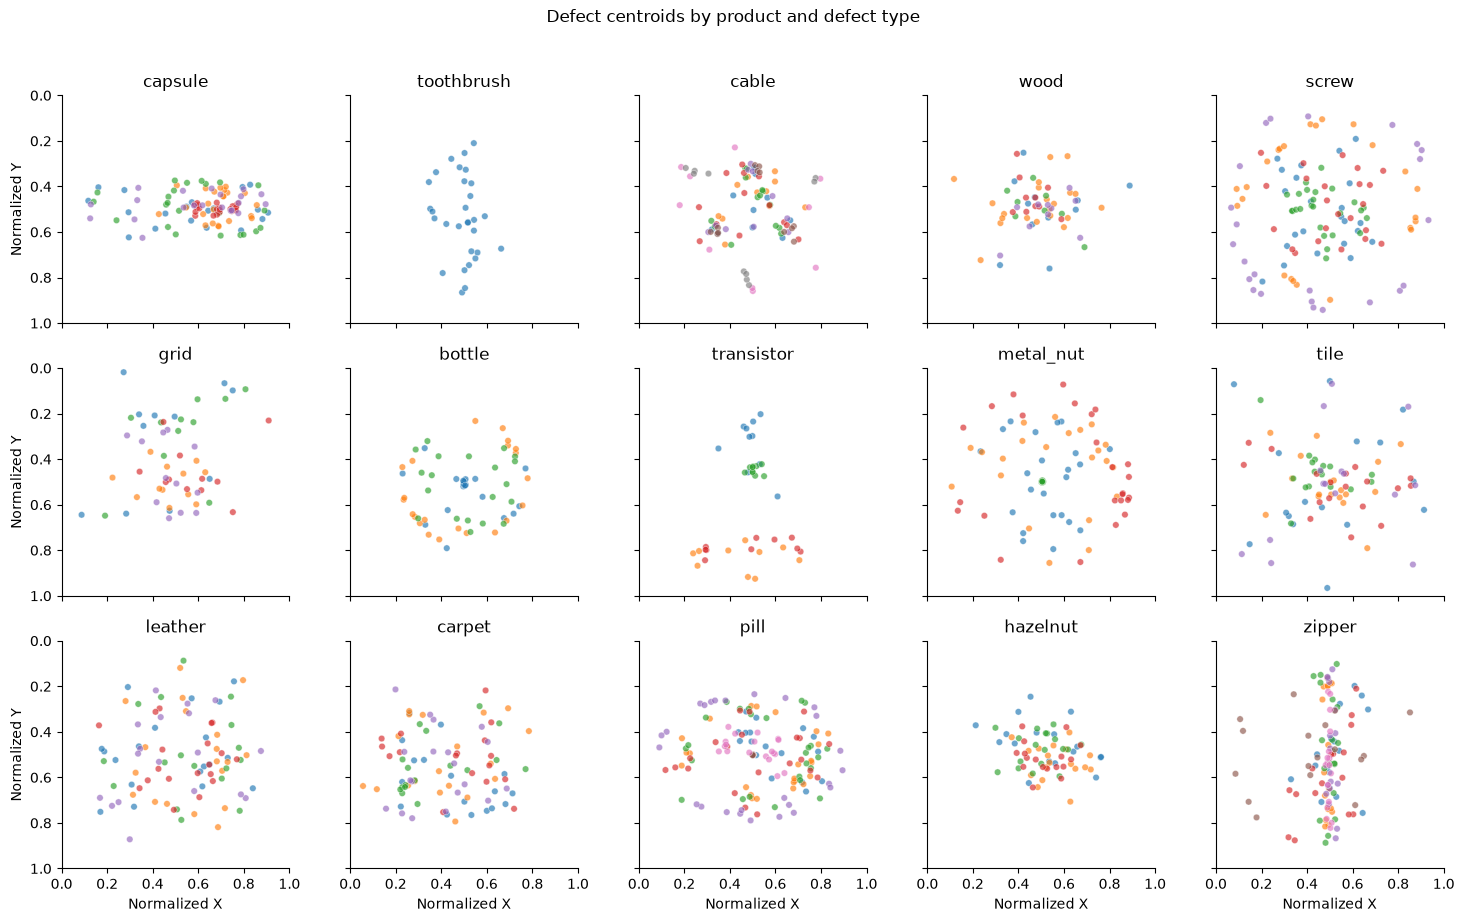

In [ ]:
g = sns.FacetGrid(mask_df, col='product', col_wrap=5, height=3, aspect=1)
g.map_dataframe(
    sns.scatterplot,
    x='centroid_x_norm',
    y='centroid_y_norm',
    hue='defect_type',
    s=22,
    alpha=0.65,
    legend=False,
)

for ax in g.axes.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(ax.get_title().replace('product = ', ''))

g.set_axis_labels('Normalized X', 'Normalized Y')
g.fig.suptitle('Defect centroids by product and defect type', y=1.02)
plt.tight_layout()
plt.show()

Defect masks vary widely in size, shape, fragmentation, and location. Most defects occupy only a small fraction of the image, with particularly small defects in screw, capsule, leather, and grid. Grid and wood also contain sparse or disconnected anomalies, while several products exhibit border or location biases. These results motivate high-resolution, spatially sensitive models and evaluation stratified by product, defect type, and defect size.

## 8. Conclusions and modeling implications

- **Dataset structure:** Training images are normal-only, while test composition and defect-type counts vary by product. Model selection and evaluation must therefore report per-product results rather than only a global average.
- **Integrity and leakage:** The manifest checks establish complete one-to-one image–mask pairing and matching dimensions. The hash analysis explicitly reports any exact duplicates or train/test leakage.
- **Preprocessing:** Products differ in image mode and resolution, so channel handling and resizing must be defined explicitly. Product-aware preprocessing or separate product models are appropriate baselines.
- **Normal-domain shift:** Brightness and contrast comparisons between `train_good` and `test_good` reveal whether acquisition differences could be mistaken for anomalies. These statistics should be interpreted within each product.
- **Defect difficulty:** Defect area, bounding-box fill, connected components, border contact, and spatial location describe complementary aspects of difficulty. Small, thin, fragmented, or border-touching defects may require higher-resolution and more spatially sensitive models.
- **Evaluation:** Use both image-level and pixel-level metrics, report them per product and defect type, and inspect performance as a function of defect size.

The next stage should establish preprocessing and baseline anomaly-detection models.

## Interactive image browser

In [26]:
import math
import ipywidgets as widgets
from IPython.display import display

browser_df = df.loc[
    (df['kind'] == 'image') & (df['split'] == 'test')
].reset_index(drop=True)
images_per_page = 8

product_widget = widgets.Dropdown(
    options=['All', *sorted(browser_df['product'].unique())],
    description='Product:',
)
defect_widget = widgets.Dropdown(description='Defect:')
good_widget = widgets.Checkbox(value=False, description='Show good images')
mask_widget = widgets.Checkbox(value=False, description='Show mask')
previous_button = widgets.Button(description='Previous', icon='arrow-left')
next_button = widgets.Button(description='Next', icon='arrow-right')
page_dropdown = widgets.Dropdown(
    options=[1], value=1, description='Page:',
    layout=widgets.Layout(width='140px'),
)
page_count_label = widgets.Label()
page_state = {'value': 1}
page_sync = {'active': False}
browser_output = widgets.Output()


def get_browser_samples() -> pd.DataFrame:
    selected = browser_df
    if not good_widget.value:
        selected = selected.loc[~selected['is_good']]
    if product_widget.value != 'All':
        selected = selected.loc[selected['product'] == product_widget.value]
    if defect_widget.value != 'All':
        selected = selected.loc[selected['defect_type'] == defect_widget.value]
    return selected.reset_index(drop=True)


def update_defect_options(*_) -> None:
    selected = browser_df
    if not good_widget.value:
        selected = selected.loc[~selected['is_good']]
    if product_widget.value != 'All':
        selected = selected.loc[selected['product'] == product_widget.value]
    options = ['All', *sorted(selected['defect_type'].unique())]
    defect_widget.options = options
    if defect_widget.value not in options:
        defect_widget.value = 'All'


def render_browser(*_) -> None:
    selected = get_browser_samples()
    page_count = max(1, math.ceil(len(selected) / images_per_page))
    page_state['value'] = min(max(1, page_state['value']), page_count)
    current_page = page_state['value']
    previous_button.disabled = current_page == 1
    next_button.disabled = current_page == page_count
    page_sync['active'] = True
    try:
        page_dropdown.options = list(range(1, page_count + 1))
        page_dropdown.value = current_page
    finally:
        page_sync['active'] = False
    page_count_label.value = f'of {page_count}'

    start = (current_page - 1) * images_per_page
    page = selected.iloc[start:start + images_per_page]

    with browser_output:
        browser_output.clear_output(wait=True)
        if page.empty:
            print('No test images match these filters.')
            return

        ncols = 4
        nrows = math.ceil(len(page) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
        for ax in axes.flat:
            ax.axis('off')

        for ax, (_, row) in zip(axes.flat, page.iterrows()):
            image = load_image_for_display(row['path'], row['mode'])
            mask = None
            if mask_widget.value and pd.notna(row['mask_path']):
                mask = cv2.imread(str(row['mask_path']), cv2.IMREAD_GRAYSCALE)
            ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
            if mask is not None and np.any(mask):
                ax.contour(mask > 0, levels=[0.5], colors='red', linewidths=1.2)
            ax.set_title(f"{row['product']}\n{row['defect_type']} - {row['filename']}", fontsize=9)
            ax.axis('off')

        num_products = selected['product'].nunique()
        fig.suptitle(
            f'{len(selected)} test images '
            f'({num_products} product{"s" if num_products != 1 else ""}) '
            f'- page {current_page}/{page_count}'
        )
        plt.tight_layout()
        plt.show()


def change_page(step: int) -> None:
    page_state['value'] += step
    render_browser()


def go_to_page(change: dict) -> None:
    if not page_sync['active'] and change['new'] != page_state['value']:
        page_state['value'] = change['new']
        render_browser()


def reset_page(*_) -> None:
    page_state['value'] = 1
    render_browser()


update_defect_options()
product_widget.observe(update_defect_options, names='value')
product_widget.observe(reset_page, names='value')
defect_widget.observe(reset_page, names='value')
good_widget.observe(update_defect_options, names='value')
good_widget.observe(reset_page, names='value')
mask_widget.observe(render_browser, names='value')
page_dropdown.observe(go_to_page, names='value')
previous_button.on_click(lambda _: change_page(-1))
next_button.on_click(lambda _: change_page(1))

display(widgets.VBox([
    widgets.HBox([product_widget, defect_widget, good_widget, mask_widget]),
    widgets.HBox([previous_button, page_dropdown, page_count_label, next_button]),
    browser_output,
]))
render_browser()